In [1]:
pip install shap


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import shap

In [3]:
df = pd.read_csv("../data/processed_startup_data.csv")

In [4]:
X = df.drop(
    columns=[
        "unicorn",
        "estimated_revenue_usd"
    ]
)

y = df["unicorn"]

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

final_model = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=4,
    max_depth=10,
    random_state=42
)

final_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
1,funding_amount_usd,0.927908
2,employee_count,0.013168
7,country_freq,0.010218
4,funding_month,0.006356
3,funding_year,0.006288
0,founded_year,0.005768
5,startup_age,0.005752
6,investor_count,0.002769
22,funding_round_Series B,0.001141
21,funding_round_Series A,0.001133


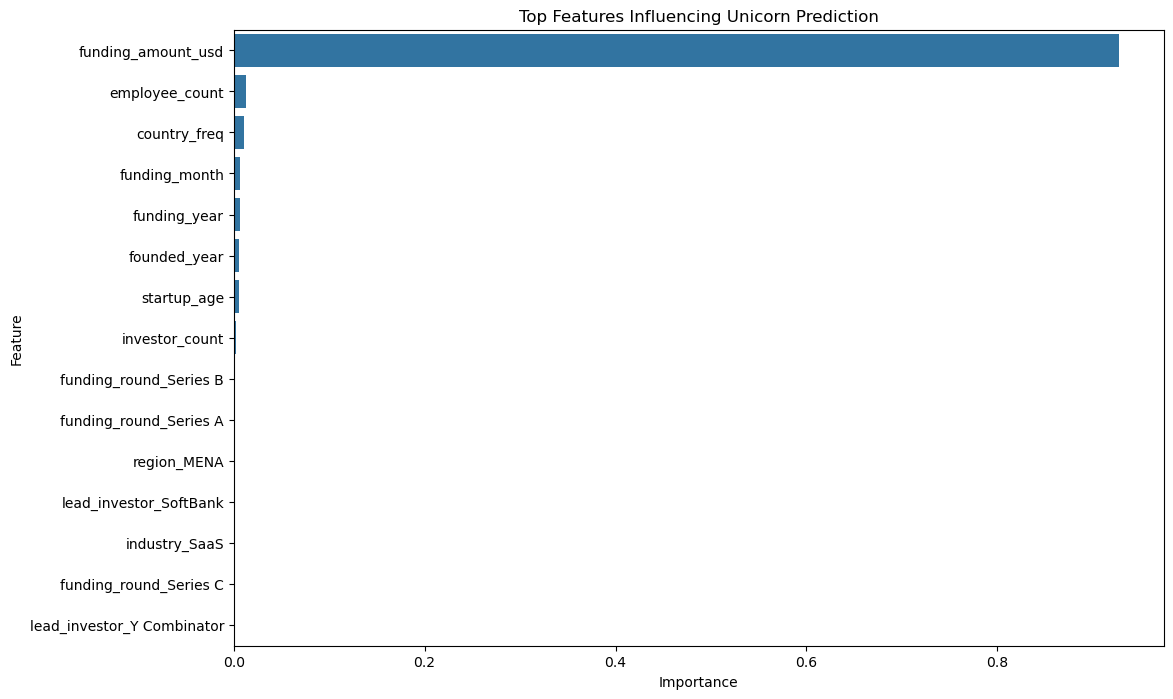

In [7]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Features Influencing Unicorn Prediction"
)

plt.show()

In [8]:
explainer = shap.TreeExplainer(
    final_model
)

In [ ]:
shap_values = explainer.shap_values(
    X_test
)

In [ ]:
shap.summary_plot(
    shap_values,
    X_test
)

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [ ]:
sample = X_test.iloc[[0]]

In [ ]:
print(type(shap_values))
print(np.array(shap_values).shape)

In [ ]:
import shap

shap.initjs()

In [ ]:
shap.force_plot(
    explainer.expected_value[1],
    shap_values[0, :, 1],
    sample
)

Business Insights

1. Funding amount is the strongest predictor of unicorn status.

2. Larger employee counts increase unicorn probability.

3. Investor participation positively impacts unicorn formation.

4. Startup age influences growth potential.

5. Country ecosystem contributes to unicorn emergence.

In [ ]:
import joblib

joblib.dump(
    final_model,
    "unicorn_predictor.pkl"
)

In [ ]:
import joblib

joblib.dump(
    final_model,
    "unicorn_predictor.pkl"
)

print("Model saved successfully")